# Título. Explicabilidad de DRL basada en árboles

**Grupo 02**
Pedro León Miranda, Likang Wu

### Resumen

El objetivo de este proyecto consiste en analizar y explicar el proceso de toma de decisiones de agentes entrenado mediante Deep Reinforcement Learning (DRL), tanto en métodos basados en políticas como en métodos basados en valor. Para ello, se ha optado por el uso de modeles basados en árbol de decisión debido a su alta interpretabilidad. derivada de su estructura de reglas explícitas.

En este contexto, se han desarrollado distintas aproximiación que dependen del tipo de aprendizaje:

- Advantage-Actor-Critic(A2C): Se ha entrenado un agente usando este método y posteriormente se han generado experiencias. Estas experiencias se han utilizado para entrenar un árbol de decisión que aproxima el comportamiento del agente. El proceso de entrenamiento del agente se encuentra en el archivo `ac2.ipynb`.

- Deep Q-Network(DQN): Del mismo modo que en el caso anterior, se ha entrenado un agente DQN y se han recolectado experiencias con las que entrenar un árbol de decisión. Dicho código se encuentra en `dqn.ipynb`. Adicionalmente, se ha entrenado mediante aprendizaje por imitación un modelo Linear Model U-Trees (LMUT), que combina estructuras de árbol con regresión lineales para aproximar el comportamietno del agetne DQN. Este enfoque actúa siguiendo al modelo "profesor" (DQN) tratand de replicar sus valores Q, y en consecuencia, su polítical. Al imitar al propio modelo y estar basado en una estructura de árbol y regresiones locales, proporciona una interpretabilidad directa. Su implementación se encuentra en lmut.ipynb.

### Contexto

El problema del aprendizaje por refuerzo surge de cuando un agente aprende mediante interacción con un entorno a través de prueba y error, recibiendo recompensas como señal de aprendizaje. A diferencia del aprendizaje por supervisado, este proceso implica secuencias de decisiones, lo que aumenta su complejidad. Además, el uso de redes neuronales profunda como agentes incrementa aún más la dificultad de interpretación del comportamiento del agente.

En este contexto, sería interesante analizar cómo influyen los diferentes parámetros del entorno en la toma de decison del agente. Para ello, se pueden plantear diversas líneas de explicación:
- Explicación de las decisiones del agente
- Explicación de la función de recompensa
- Explicación del estado
- Descomposición de tareas en subtareas explicables

En este proyecto se ha optado por la primera, ya que es la que proporciona una visión más general. En concreto, se busca interpretar cómo, a partir del entorno y de las acciones disponibles, el agente selecciona sus acciones en cada instante.

Cabe destacar que se ha utilizado el entorno CartPole, en el que el objetivo consiste en mantener en equilibrio un poste situado sobre un carro, desplazándolo hacia la izquierda o la derecha para evitar su caída.

### Datos

Como se ha mencionado anteriormente, se han utilizado dos conjuntos de datos generados por los agentes DQN y A2C tras su entrenamiento. Estos se encuentran en la carpeta `data/`, organizados según el agente al que corresponden.

### Modelos

Se han entrenado tres agentes, disponibles en la carpeta `models/`. Los dos primeros corresponden con los dos algoritmos:
- AC2, que devuelve la política representada como una distribución de probabilidad sobre las acciones.

- DQN, que estima el valor Q asociada a cada acción dado un estado.

Además, se incluye el modelo LMUT, entrenado por imitación, que aprende a aproximar el comportamiento del agente DQN y también devuelve valores Q.

### Referencias

- Toward Interpretable Deep Reinforcement Learning with Linear Model U-Trees
- https://medium.com/data-science/building-an-explainable-reinforcement-learning-framework-084ef2d23d01
- A Survey on Explainable Reinforcement Learning: Concepts, Algorithms, and Challenges
- https://gymnasium.farama.org/environments/classic_control/cart_pole/


In [1]:
FEATURE_NAMES = [
	"pos_carro",       # posición horizontal del carro
	"vel_carro",       # velocidad horizontal del carro
	"angulo_palo",     # ángulo del palo respecto a la vertical
	"vel_ang_palo",    # velocidad angular del palo
]

ACTION_NAMES = [
	"izquierda",   # 0: empujar carro a la izquierda
	"derecha",     # 1: empujar carro a la derecha
]

In [2]:
import torch
import numpy as np
import gymnasium as gym
import shap
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
from dqn import DQNAgent, DQNNetwork
from stable_baselines3 import A2C
from visualization import show_animation_with_decision_path, plot_correlation_matrix
from IPython.display import HTML
from lmut import LMUT
import os


c:\Users\malos\Documents\GitHub\XRL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
env = gym.make('CartPole-v1', render_mode="rgb_array")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print(state_size, action_size)


4 2


In [4]:
def evaluar_politica_arbol(env: gym.Env, tree: DecisionTreeClassifier, n_episodes: int = 20):
	rewards = []
	for _ in range(n_episodes):
		obs, _ = env.reset()
		done, total = False, 0.0
		while not done:
			action = int(tree.predict(obs.reshape(1, -1))[0])
			obs, r, term, trunc, _ = env.step(action)
			total += r
			done = term or trunc
		rewards.append(total)
	return np.mean(rewards), np.std(rewards)


In [5]:
def explain_action_tree(state: np.ndarray, tree: DecisionTreeClassifier, feature_names: list[str]):
    node_ids = tree.decision_path(state.reshape(1, -1)).indices
    rules = []
    for node in node_ids[:-1]:
        feat = feature_names[tree.tree_.feature[node]]
        thr = tree.tree_.threshold[node]
        val = state[tree.tree_.feature[node]]
        rules.append((feat, "<=" if val <= thr else ">", thr, val))

    action_taken = tree.predict(state.reshape(1, -1))[0]
    return action_taken, rules


# DQN

DQN es un algoritmo de reinforcement learning basado en value-based learning. Su idea central consiste en aprender una función Q(s,a), que representa el retorno esperado acumulado cuando el agente se encuentra en un estado s y ejecuta la acción a con una política concreta.

Formalmente, el modelo aproxima:
- Q(s,a) = retorno esperado si tomas acción a en estado s

Una vez entrenado el agente, en cada estado se selecciona la acción con mayor valor Q(s,a), es decir la política se define implícitamente como:
- política(s) argmax a Q(s,a)

Entre sus características destacan:
- Solo funciona con acciones discretas.
- La política no se aprende explícitamente, sino que induce a partir de los valores Q.
- El entrenamiento se basa en una política epsilon greedy, que equilibra exploración y explotación. En ausencia de exploración (epsilon = 0), el comportamiento del agente es completamente determinista.


In [6]:
models_dir = "./models"

final_model_path = os.path.join(models_dir, "dqn_cartpole")

data_dir = "./data"
a2c_data_dir = os.path.join(data_dir, "dqn")

x_path = os.path.join(a2c_data_dir, "X_cartpole.npy")
y_path = os.path.join(a2c_data_dir, "y_cartpole.npy")

print(final_model_path)


./models\dqn_cartpole


In [7]:
agent = DQNAgent(state_size, action_size)
agent.load(final_model_path)

X = np.load(x_path)
y = np.load(y_path)


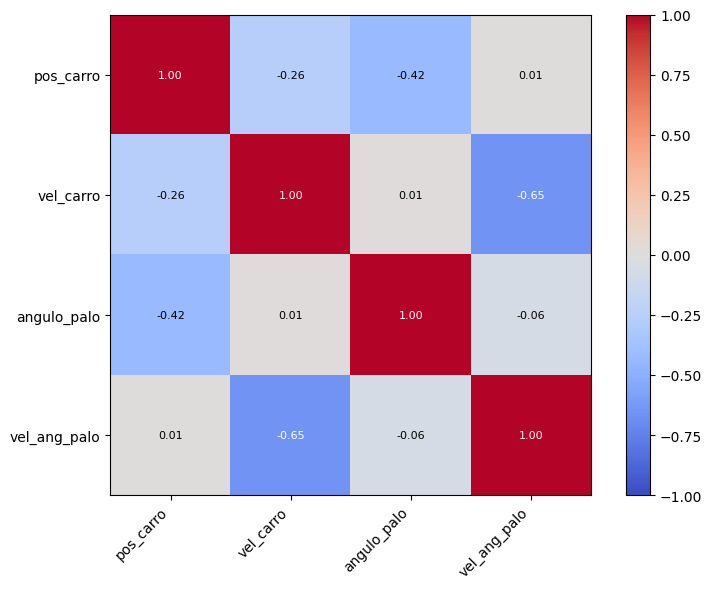

In [8]:
plot_correlation_matrix(X, FEATURE_NAMES)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)


In [10]:
explainer = shap.KernelExplainer(
    agent.predict_batch, 
    shap.sample(X_train, 1000)
)

shap_values = explainer.shap_values(X_test[:500])


Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 500/500 [00:03<00:00, 133.03it/s]


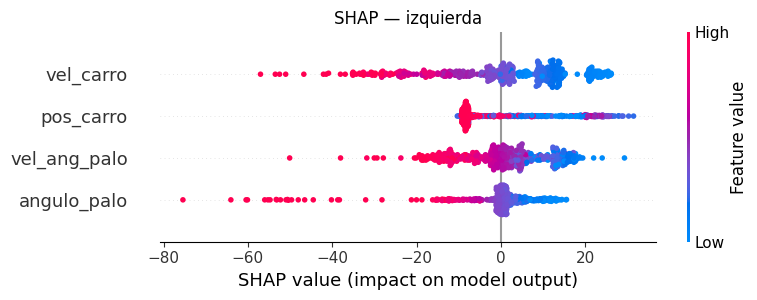

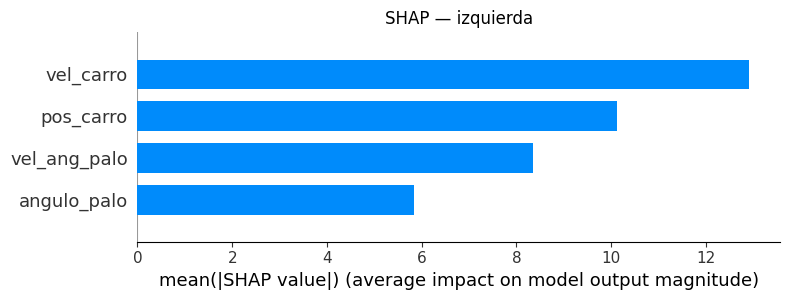

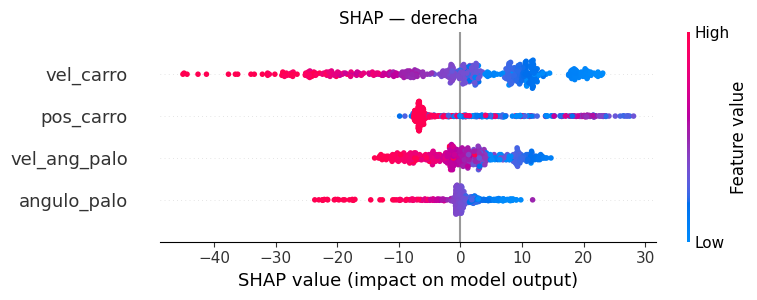

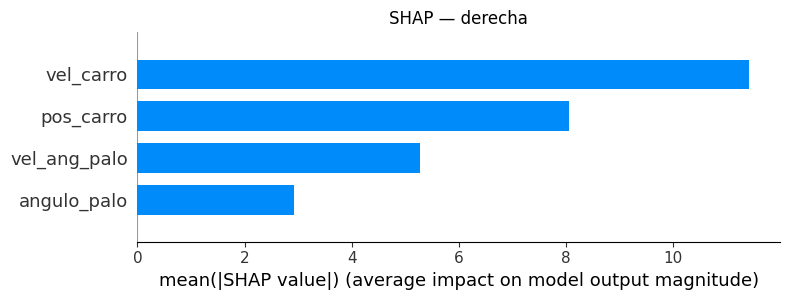

In [11]:
shap_arr = np.array(shap_values)

for i in range(len(ACTION_NAMES)):
	shap.summary_plot(shap_arr[:, :, i], X_test[:500],feature_names=FEATURE_NAMES, show=False)
	plt.title(f"SHAP — {ACTION_NAMES[i]}")
	plt.tight_layout()
	plt.show()

	shap.summary_plot(shap_arr[:, :, i], X_test[:500],feature_names=FEATURE_NAMES, plot_type="bar", show=False)
	plt.title(f"SHAP — {ACTION_NAMES[i]}")
	plt.tight_layout()
	plt.show()


In [12]:
tree = DecisionTreeClassifier(max_depth=6)
tree.fit(X_train, y_train)

print(f"Fidelidad (accuracy vs DQN): {accuracy_score(y_test, tree.predict(X_test)):.3f}")
print(classification_report(y_test, tree.predict(X_test), target_names=ACTION_NAMES))


Fidelidad (accuracy vs DQN): 0.892
              precision    recall  f1-score   support

   izquierda       0.89      0.89      0.89      5000
     derecha       0.89      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [13]:
for d in [2, 3, 4, 5, 6, 8, 10, 15, 20]:
	t = DecisionTreeClassifier(max_depth=d).fit(X_train, y_train)
	print(f"depth={d:2d}  fidelidad={accuracy_score(y_test, t.predict(X_test)):.3f}")


depth= 2  fidelidad=0.798
depth= 3  fidelidad=0.836
depth= 4  fidelidad=0.854
depth= 5  fidelidad=0.870
depth= 6  fidelidad=0.892
depth= 8  fidelidad=0.913
depth=10  fidelidad=0.925
depth=15  fidelidad=0.933
depth=20  fidelidad=0.932


|--- vel_ang_palo <= 0.02
|   |--- vel_ang_palo <= -0.07
|   |   |--- angulo_palo <= 0.03
|   |   |   |--- vel_ang_palo <= -0.15
|   |   |   |   |--- pos_carro <= 0.20
|   |   |   |   |   |--- vel_carro <= 0.80
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_carro >  0.80
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- pos_carro >  0.20
|   |   |   |   |   |--- vel_carro <= 0.06
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_carro >  0.06
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- vel_ang_palo >  -0.15
|   |   |   |   |--- angulo_palo <= 0.00
|   |   |   |   |   |--- pos_carro <= 1.54
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pos_carro >  1.54
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- angulo_palo >  0.00
|   |   |   |   |   |--- pos_carro <= 0.63
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pos_carro >  0.63
|   |   |   |   |   |   |--- class: 1
|   |   |--- angulo_palo

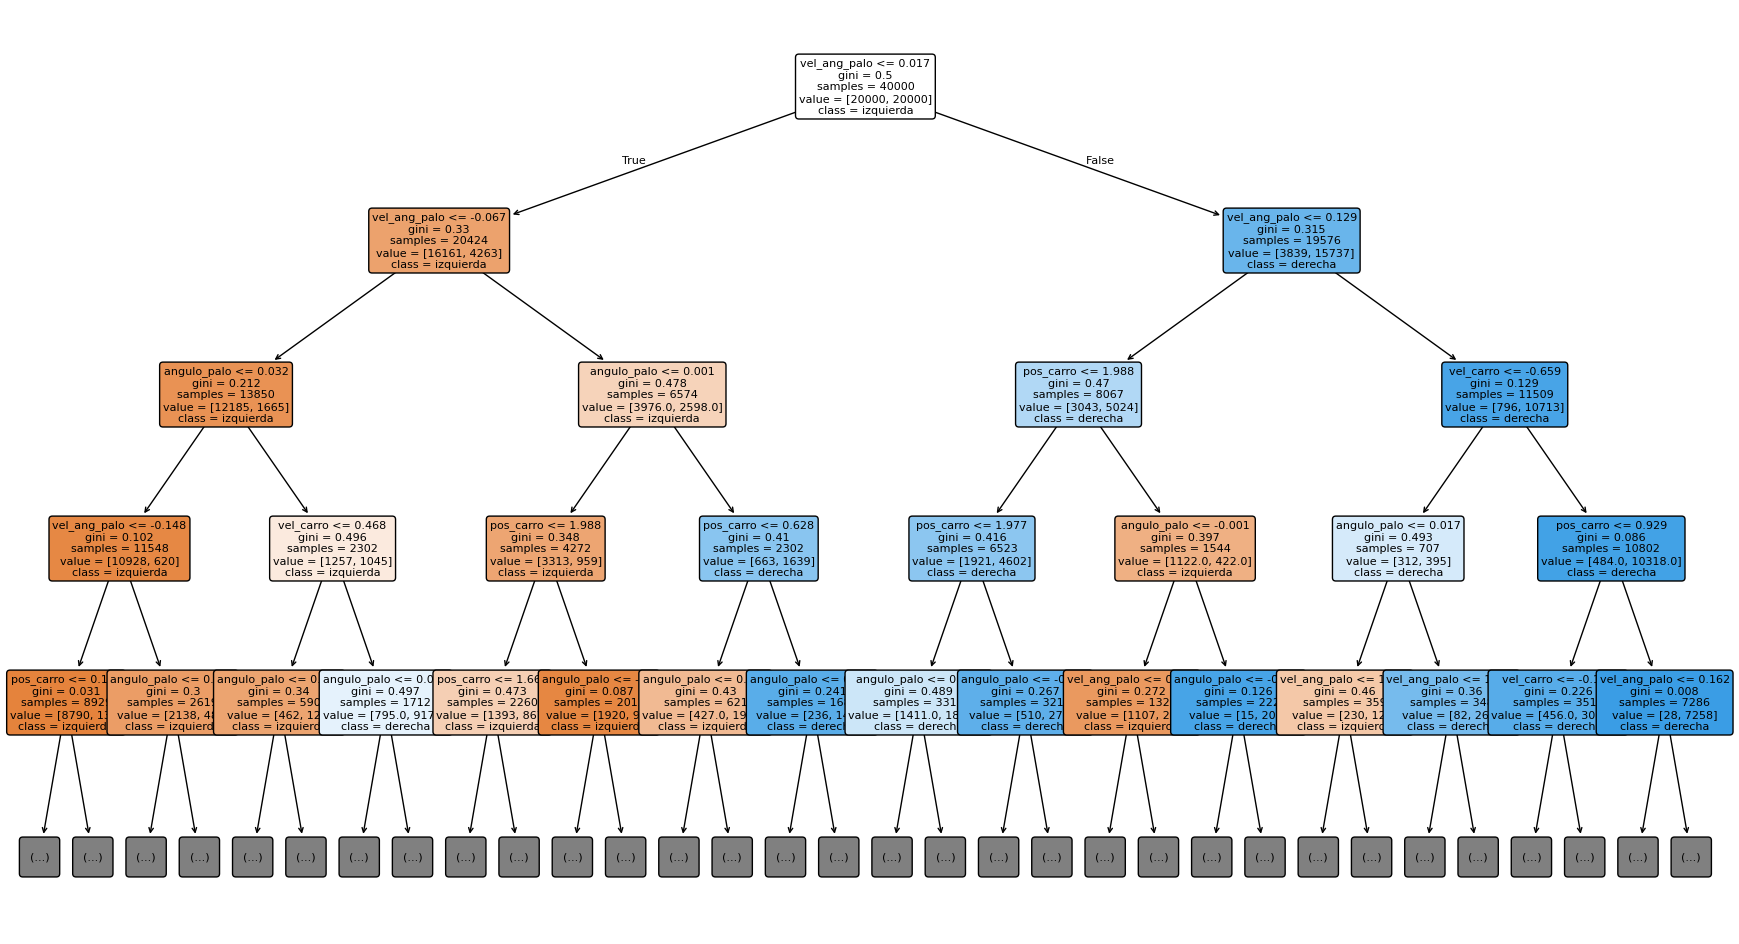

In [14]:
print(export_text(tree, feature_names=FEATURE_NAMES))

plt.figure(figsize=(22, 12))
plot_tree(
	tree,
	feature_names=FEATURE_NAMES,
	class_names=ACTION_NAMES,
	filled=True,
	rounded=True,
	fontsize=8,
	max_depth=4,  # recorta el dibujo para que sea legible
)
plt.show()


In [15]:
m, s = evaluar_politica_arbol(env, tree)
print(f"Recompensa del árbol sustituto: {m:.1f} ± {s:.1f}")


Recompensa del árbol sustituto: 412.9 ± 113.0


vel_ang_palo    0.653371
angulo_palo     0.202745
pos_carro       0.112785
vel_carro       0.031099
dtype: float64


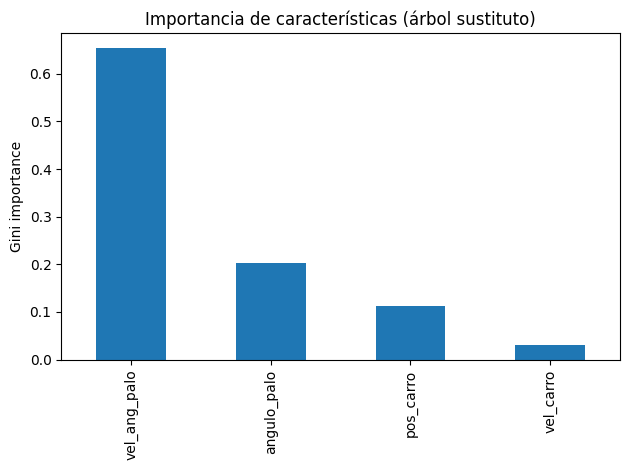

In [ ]:
imp = pd.Series(tree.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp)

imp.plot(kind="bar", title="Importancia de características (árbol sustituto)", ylabel="Gini importance")
plt.tight_layout()
plt.show()


# A2C

El método Actor-Critic pertenece a la familia de algoritmos basados en política. Este enfoque se compone de dos componenes principales:
- Actor: responsable de aprender la política del agente. Recibe el estado y produce una distribución de probabilidad sobre las acciones posibles.
- Critic: evalúa la calidad del estado estimando un valor escalar, que generalmente corresponde con V(s), es decir, el retorno esperado desde ese estado siguiendo una política concreta.

A diferencia de métodos basados en valores como DQN, la política es explícita, ya que el actor es el que la representa.

Entre sus principales características destacan:
- Puede trabajar tanto con espacios de acciones discretas como continuas.
- La política es explícita y parametrizada por el actor.
- El comportamiento del agente es estocástico, ya que las acciones se muestrean a partir de la distribución de probabilidad generada por el actor.


In [17]:
a2c_path = os.path.join(models_dir, "a2c")

data_dir = "./data"
a2c_data_dir = os.path.join(data_dir, "a2c")
os.makedirs(a2c_data_dir, exist_ok=True)

x_path = os.path.join(a2c_data_dir, "X_cartpole.npy")
y_path = os.path.join(a2c_data_dir, "y_cartpole.npy")


In [18]:
best_model = A2C.load(a2c_path)

X = np.load(x_path)
y = np.load(y_path)


c:\Users\malos\Documents\GitHub\XRL\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


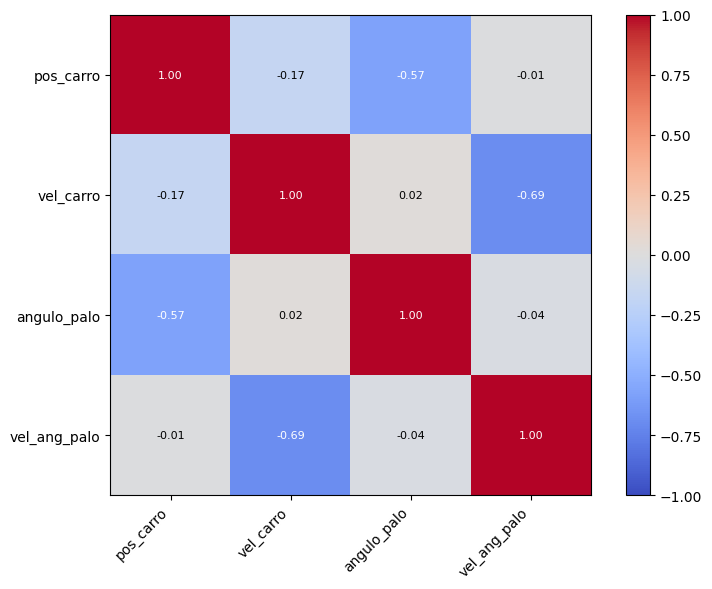

In [19]:
plot_correlation_matrix(X, FEATURE_NAMES)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)


In [21]:
def politica_proba(obs_batch):
    device = best_model.policy.device
    obs_t = torch.as_tensor(obs_batch, dtype=torch.float32, device=device)
    dist = best_model.policy.get_distribution(obs_t)
    probs = dist.distribution.probs.detach().cpu().numpy()
    return probs[:, 1]

explainer = shap.KernelExplainer(politica_proba, shap.sample(X_train, 10000))
shap_values = explainer.shap_values(X_test[:500])
print("SHAP values calculados. Tipo:", type(shap_values))


Using 10000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 500/500 [00:08<00:00, 61.12it/s]

SHAP values calculados. Tipo: <class 'numpy.ndarray'>


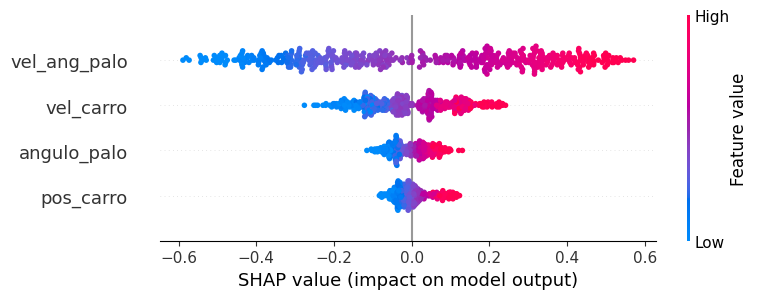

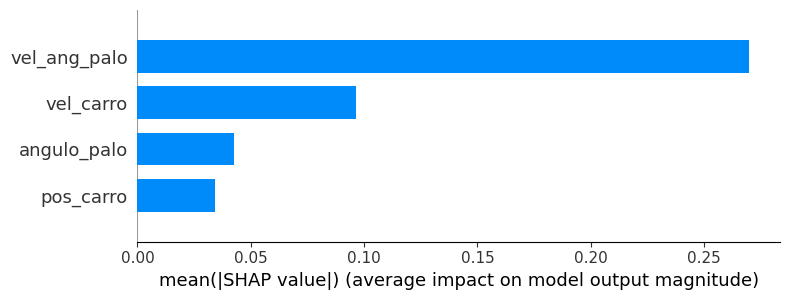

In [22]:
shap.summary_plot(shap_values, X_test[:500], feature_names=FEATURE_NAMES)
shap.summary_plot(shap_values, X_test[:500], feature_names=FEATURE_NAMES, plot_type="bar")


In [23]:
tree = DecisionTreeClassifier(max_depth=6)
tree.fit(X_train, y_train)

print(f"Fidelidad (accuracy vs A2C): {accuracy_score(y_test, tree.predict(X_test)):.3f}")
print(classification_report(y_test, tree.predict(X_test), target_names=ACTION_NAMES))


Fidelidad (accuracy vs A2C): 0.967
              precision    recall  f1-score   support

   izquierda       0.96      0.97      0.97      9998
     derecha       0.97      0.96      0.97     10002

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



In [24]:
# Barrido de profundidades para elegir el mejor trade-off
for d in [2, 3, 4, 5, 6, 8, 10, 15, 20]:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    print(f"depth={d:2d}  fidelidad={accuracy_score(y_test, t.predict(X_test)):.3f}")


depth= 2  fidelidad=0.889
depth= 3  fidelidad=0.943
depth= 4  fidelidad=0.948
depth= 5  fidelidad=0.959
depth= 6  fidelidad=0.967
depth= 8  fidelidad=0.979
depth=10  fidelidad=0.984
depth=15  fidelidad=0.986
depth=20  fidelidad=0.986


|--- vel_ang_palo <= 0.00
|   |--- vel_ang_palo <= -0.07
|   |   |--- vel_ang_palo <= -0.12
|   |   |   |--- vel_ang_palo <= -0.15
|   |   |   |   |--- vel_carro <= 0.60
|   |   |   |   |   |--- vel_ang_palo <= -0.15
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_ang_palo >  -0.15
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- vel_carro >  0.60
|   |   |   |   |   |--- vel_ang_palo <= -0.17
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_ang_palo >  -0.17
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- vel_ang_palo >  -0.15
|   |   |   |   |--- vel_carro <= 0.39
|   |   |   |   |   |--- pos_carro <= -0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pos_carro >  -0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- vel_carro >  0.39
|   |   |   |   |   |--- angulo_palo <= -0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- angulo_palo >  -0.01
|   |   |   |   |   |   |--- class: 1
| 

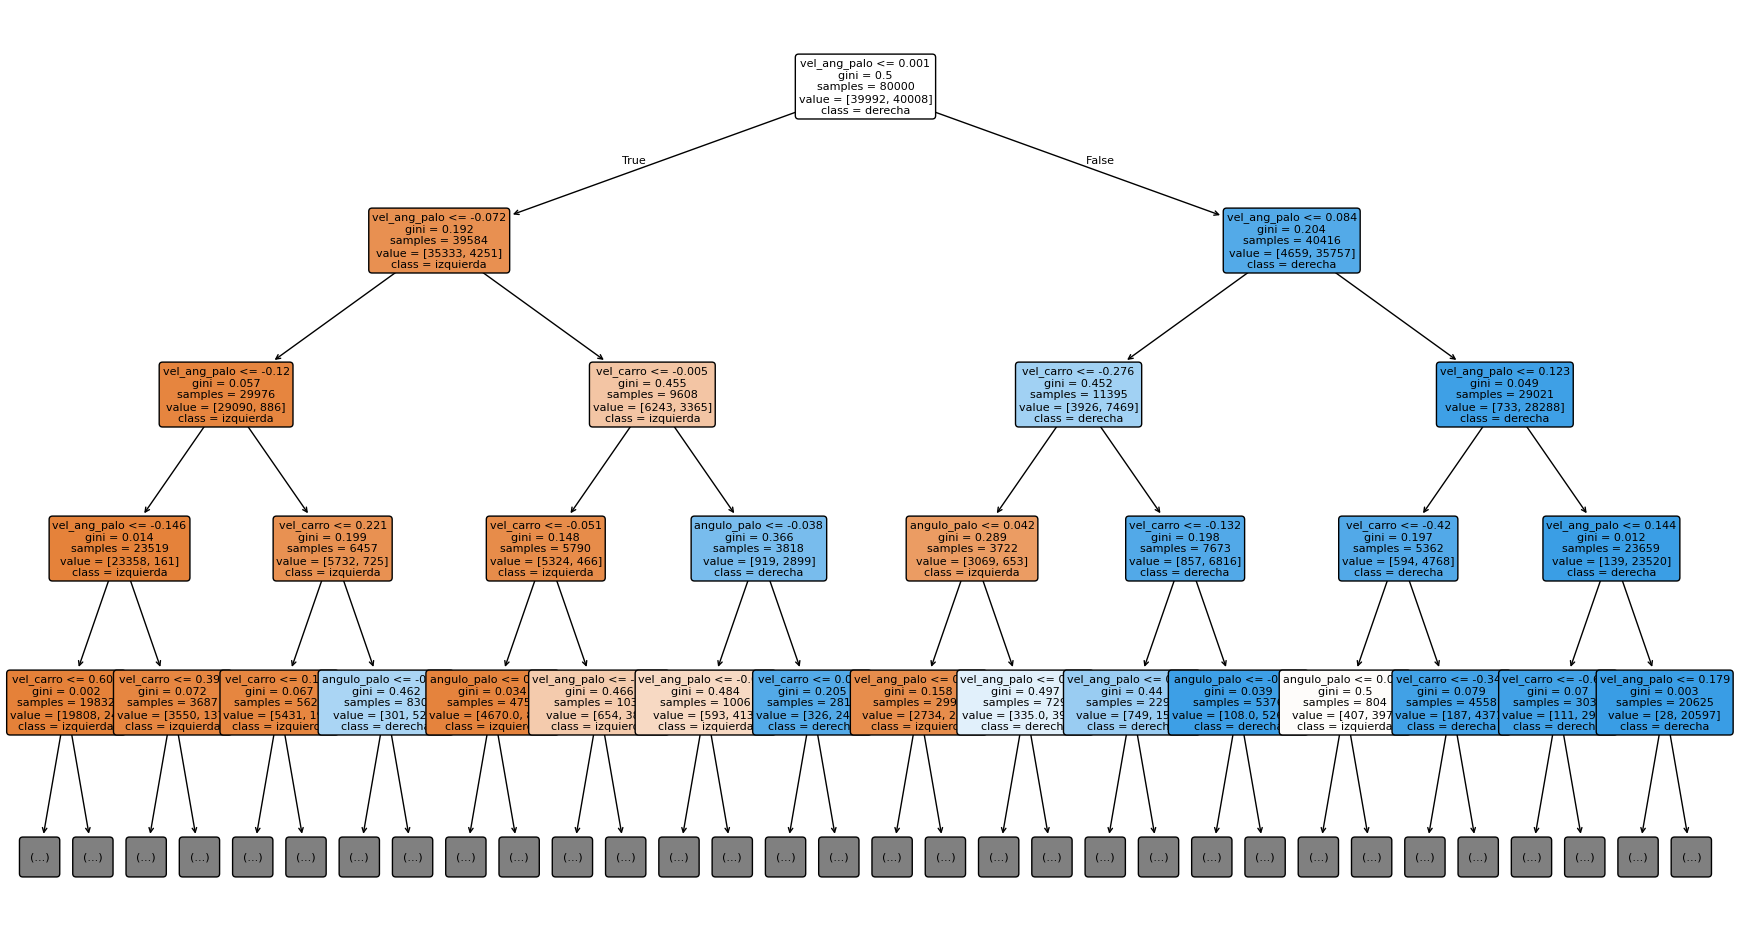

In [25]:
# Reglas legibles en texto
print(export_text(tree, feature_names=FEATURE_NAMES))

# Árbol gráfico
plt.figure(figsize=(22, 12))
plot_tree(
    tree,
    feature_names=FEATURE_NAMES,
    class_names=ACTION_NAMES,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,  # recorta el dibujo para que sea legible
)
plt.show()


In [26]:
m, s = evaluar_politica_arbol(env, tree)
print(f"Recompensa del árbol sustituto: {m:.1f} ± {s:.1f}")


Recompensa del árbol sustituto: 500.0 ± 0.0


vel_ang_palo    0.780866
vel_carro       0.177762
angulo_palo     0.034948
pos_carro       0.006425
dtype: float64


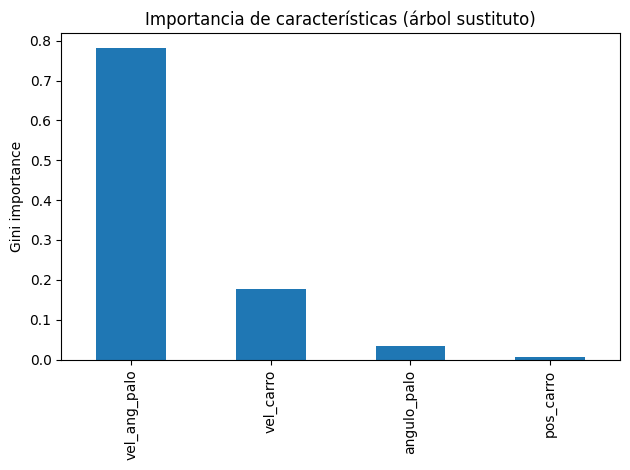

In [27]:
imp = pd.Series(tree.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp)

imp.plot(kind="bar", title="Importancia de características (árbol sustituto)", ylabel="Gini importance")
plt.tight_layout()
plt.show()


In [28]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

frames, explanations = [], []
state, _ = env.reset()
state = np.array(state, dtype=np.float32)
done = False

while not done:
    frames.append(env.render())
    action, _ = best_model.predict(state, deterministic=True)
    action_taken, rules = explain_action_tree(state, tree, FEATURE_NAMES)

    explanations.append({
        "action": ACTION_NAMES[action], 
        "action_tree": ACTION_NAMES[action_taken], 
        "match": action == action_taken, 
        "rules": rules,
        "gini": tree.tree_.impurity[tree.apply(state.reshape(1, -1))[0]]

    })

    state, reward, terminated, truncated, _ = env.step(action)
    state = np.array(state, dtype=np.float32)
    done = terminated or truncated

env.close()


c:\Users\malos\Documents\GitHub\XRL\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [29]:
ani = show_animation_with_decision_path(frames[:10], explanations[:10])

HTML(ani.to_jshtml())


# LMUT

El model Linear Model U-Trees (LMUT) presentado en "Toward Interpretable Deep Reinforcement Learning with Linear Model U-Trees" prpone un enfoque de aprendizaje por imitación en el que se aproximan los valores Q devueltos por un agente por refuerzo de DQN previamente entrenado.

La principal contribución de este método reside en su estructura intrínsecamente explicativa basada en árbol en la que se construye un árbol por cada acción. Estos árboles particionan el espacio de estados, de forma que los nodos internos dividen el espacio en función de los atributos, mientra que los nodos hoja ajustan modelos de regresión lineal. Esta idea se basa en que múltiples modelos lineales bien dividido pueden aproximar una función más compleja.

En cada hoja, el valor Q se aroxima mediante un modelo lineal de la forma:
- Q(s, a) = w(s) * s + b,
donde la acción (a) depende del árbol escogido.

De este modo, el modelo final es capaz de imitar el comportamiento del agente profesor (DQN), reproduciendo sus valores Q con una elevada interpretabilidad, ya que combina particiones basadas en árboles con modelos lineales locales.

Además, se trata de un método post-hoc, ya que el agente original previamente entrenado se ejecuta nuevamente con la política epsilon greedy para generar datos de entrenamiento para el árbol. En este proceso, el modelo no solo aprende el comportamiento óptimo del agente, sino también su dinámica de exploración. Como consecuencia, al principio, cuando hay mayor exploración, crecen los árboles, mientras que en fases de explotación se refinan las hojas.

Finalmetne, cabe destacar que se puede calcular la importancia de las variables del estado utilizando las varianzas de los atributos al momento de realizar una partición.


In [30]:
lmut_path = os.path.join(models_dir, "lmut")


In [31]:
lmut2 = LMUT.load(lmut_path)


In [32]:
lmut2.print_tree(0)



=== Tree for action 0 ===
[Node] depth=0 | split: feature 2 < 0.0339
  left:
    [Node] depth=1 | split: feature 3 < -0.5969
      left:
        [Node] depth=2 | split: feature 2 < -0.1404
          left:
            [Node] depth=3 | split: feature 3 < -1.1224
              left:
                [Leaf] depth=4 | y = [-0.25606263 -2.9763227   0.8535153   5.4411955 ] * s + -3.4513
              right:
                [Node] depth=4 | split: feature 2 < -0.1747
                  left:
                    [Leaf] depth=5 | y = [-0.28694424 -1.7148706   0.9133243   5.064696  ] * s + -2.5158
                  right:
                    [Leaf] depth=5 | y = [-0.7009262 -1.2969786  0.7360002  4.297541 ] * s + -1.2241
          right:
            [Node] depth=3 | split: feature 3 < -1.1691
              left:
                [Node] depth=4 | split: feature 2 < -0.0955
                  left:
                    [Leaf] depth=5 | y = [ 0.0769522  -0.7658461   0.36850435  1.3220507 ] * s + -0.4749

In [33]:
print("\n=== Feature Influence ===")
for i, inf in enumerate(lmut2.feature_influence):
	print(f"{FEATURE_NAMES[i]} : {inf:.6f}")
	


=== Feature Influence ===
pos_carro : 11.449128
vel_carro : 6.113397
angulo_palo : 243.934555
vel_ang_palo : 636.434060


vel_ang_palo    636.434060
angulo_palo     243.934555
pos_carro        11.449128
vel_carro         6.113397
dtype: float64


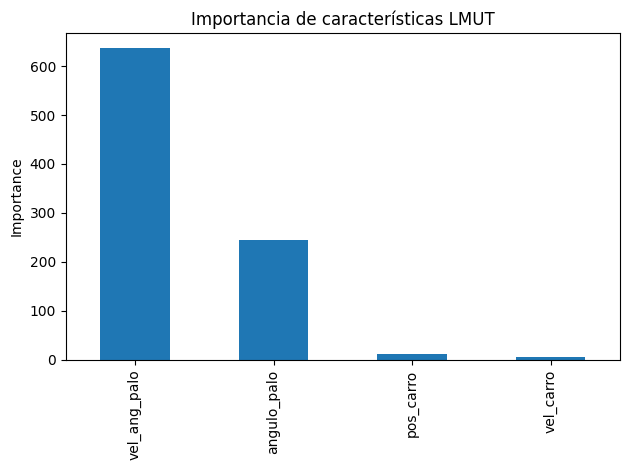

In [34]:
imp = pd.Series(lmut2.feature_influence, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp)

imp.plot(kind="bar", title="Importancia de características LMUT", ylabel="Importance")
plt.tight_layout()
plt.show()


# Conclusión

Los resultados muestran que `vel_ang_palo` es la variable más determinante en la toma de decisión del agente. Esto es coherente ya que es la señal de peligro más inmediata al anticipar la caída del palo antes de que el ángulo sea crítico. Por otro lado, la variable menos influyente es `pos_carro`, lo cual también es consistente porque la posición absoluta del carro importa poco mientras el palo no caiga, ya que el agente prioriza el equilibrio del sistema.

En el caso de DQN, esto no se aprecia directamente en su gráfica SHAP, ya que estas se aplican sobre valores Q en lugar de probabilidades. En constraste, en A2C, cuya política es estocástica y produce distribuciones de probabilidad, las interpretaciones son más claras.

Esta diferencia es una limitación inherente de DQN, ya que al ser un agente determinista basado en valores, no existe una noción explícita de confianza o probabilidad sobre las acciones, lo que reduce la riqueza informativa de SHAP aplicado directamente sobre la red.

Finalmente, LMUT se trata de un agente inherentemente interpretable, lo que le aporta una gran capacidad de explicabilidad de forma natural. Sin embargo su legibilidad puede verse comprometida cuando intenta aproximar políticas complejas, ya que el número de nodos, y especialmente de hojas, puede aumentar considerablemente.
